<a href="https://colab.research.google.com/github/josetingeo/cucumber_leaf_disease_detiction/blob/main/Leaf_Disease_Detection_Using_K_Means_Clustering_and_Random_Forest_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# CELL 1: Setup, Mount Drive & Initialize Paths
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import joblib
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from google.colab import files
from IPython.display import display, HTML

# --- YOUR PROJECT DIRECTORIES ---
PROJECT_PATH = "/content/drive/MyDrive/mini project"
DATASET_PATH = os.path.join(PROJECT_PATH, "Dataset/cucumber_Leaf_Disease")
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
TEST_PATH    = os.path.join(DATASET_PATH, "test")
MODEL_PATH   = os.path.join(PROJECT_PATH, "Model")

os.makedirs(MODEL_PATH, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
IMAGE_SIZE = (256, 256)

# Verify directories
print("Checking Paths:")
print("📁 Train Path:", TRAIN_PATH, "--> Exists:", os.path.exists(TRAIN_PATH))
print("📁 Test Path :", TEST_PATH,  "--> Exists:", os.path.exists(TEST_PATH))
print("📁 Model Path:", MODEL_PATH)

# Detect disease classes dynamically from the train folder
CLASS_NAMES = sorted([
    f for f in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, f)) and not f.startswith('.')
])
print(f"\n✅ Detected {len(CLASS_NAMES)} Disease Classes: {CLASS_NAMES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking Paths:
📁 Train Path: /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train --> Exists: True
📁 Test Path : /content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/test --> Exists: True
📁 Model Path: /content/drive/MyDrive/mini project/Model

✅ Detected 4 Disease Classes: ['Downy_mildew', 'Healthy_leaves', 'Model', 'Powdery_mildew']


In [ ]:
# ==============================================================================
# CELL 2: Color Space Conversion, K-Means (k=2) & 13 GLCM Feature Extraction
# ==============================================================================

FEATURE_NAMES = [
    "contrast", "correlation", "energy", "homogeneity", "entropy",
    "dissimilarity", "variance", "std_dev", "mean",
    "maximum", "minimum", "median", "range"
]

def preprocess_and_segment(image_path, target_size=IMAGE_SIZE):
    """
    Paper Pipeline:
    1. RGB Image Resizing
    2. Conversion to LAB Color Space (Section 3.2)
    3. Segmentation via K-Means Clustering (k=2) (Section 3.3)
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None, None, None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, target_size)

    # Convert to LAB color space
    lab_img = cv2.cvtColor(img_resized, cv2.COLOR_RGB2LAB)

    # K-Means Clustering (k=2)
    pixel_values = lab_img.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, _ = cv2.kmeans(pixel_values, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    seg_mask = labels.reshape(img_resized.shape[:2]).astype(np.uint8)

    # Isolate leaf foreground
    if np.sum(seg_mask == 0) > np.sum(seg_mask == 1):
        seg_mask = (seg_mask == 1).astype(np.uint8) * 255
    else:
        seg_mask = (seg_mask == 0).astype(np.uint8) * 255

    gray_img = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    roi = cv2.bitwise_and(gray_img, gray_img, mask=seg_mask)

    return img_resized, lab_img, seg_mask, roi


def extract_13_glcm_features(roi_img, mask):
    """
    Extracts the exact 13 GLCM and statistical features from Section 3.4 of the paper:
    1. Contrast, 2. Correlation, 3. Energy, 4. Homogeneity, 5. Entropy,
    6. Dissimilarity, 7. Variance, 8. Std Dev, 9. Mean, 10. Max,
    11. Min, 12. Median, 13. Range
    """
    pixels = roi_img[mask > 0]
    if len(pixels) == 0:
        return [0.0] * 13

    # GLCM matrix computation (distance=1, angle=0)
    glcm = graycomatrix(roi_img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    # Haralick Texture Properties
    contrast = float(graycoprops(glcm, 'contrast')[0, 0])
    correlation = float(graycoprops(glcm, 'correlation')[0, 0])
    energy = float(graycoprops(glcm, 'energy')[0, 0])
    homogeneity = float(graycoprops(glcm, 'homogeneity')[0, 0])
    dissimilarity = float(graycoprops(glcm, 'dissimilarity')[0, 0])

    # GLCM Entropy
    glcm_flat = glcm.flatten()
    non_zero = glcm_flat[glcm_flat > 0]
    glcm_entropy = float(entropy(non_zero))

    # Statistical Intensity Distribution from ROI
    variance_val = float(np.var(pixels))
    std_val = float(np.std(pixels))
    mean_val = float(np.mean(pixels))
    max_val = float(np.max(pixels))
    min_val = float(np.min(pixels))
    median_val = float(np.median(pixels))
    range_val = max_val - min_val

    return [
        contrast, correlation, energy, homogeneity, glcm_entropy,
        dissimilarity, variance_val, std_val, mean_val,
        max_val, min_val, median_val, range_val
    ]

print("✅ Image Processing & Feature Extraction functions compiled.")

✅ Image Processing & Feature Extraction functions compiled.


In [ ]:
# ==============================================================================
# CELL 3: Feature Extraction Across Train and Test Sets
# ==============================================================================

def load_and_extract_features(split_path, split_name="train", force_refresh=True):
    csv_cache = os.path.join(MODEL_PATH, f"{split_name}_features.csv")

    if os.path.exists(csv_cache) and not force_refresh:
        print(f"📂 Loading cached {split_name} features from: {csv_cache}")
        return pd.read_csv(csv_cache)

    print(f"\n🔍 Extracting features from {split_name} set ({split_path})...")
    data_rows = []

    for class_idx, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(split_path, class_name)
        if not os.path.isdir(folder):
            continue

        file_list = [f for f in os.listdir(folder) if f.lower().endswith(IMAGE_EXTENSIONS)]
        print(f"  --> {class_name}: {len(file_list)} images")

        for file_name in file_list:
            full_path = os.path.join(folder, file_name)
            _, _, mask, roi = preprocess_and_segment(full_path)
            if roi is None:
                continue

            feats = extract_13_glcm_features(roi, mask)
            row = feats + [class_idx, class_name]
            data_rows.append(row)

    cols = FEATURE_NAMES + ["label", "class_name"]
    df = pd.DataFrame(data_rows, columns=cols)

    # Save to Google Drive
    df.to_csv(csv_cache, index=False)
    print(f"✅ Saved features to: {csv_cache} (Total: {len(df)} images)")
    return df

# Extract Train and Test
train_df = load_and_extract_features(TRAIN_PATH, "train", force_refresh=True)
test_df  = load_and_extract_features(TEST_PATH, "test", force_refresh=True)

print(f"\n✅ Train Data Shape: {train_df.shape}")
print(f"✅ Test Data Shape : {test_df.shape}")


🔍 Extracting features from train set (/content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/train)...
  --> Downy_mildew: 1284 images
  --> Healthy_leaves: 1229 images
  --> Model: 0 images
  --> Powdery_mildew: 1190 images
✅ Saved features to: /content/drive/MyDrive/mini project/Model/train_features.csv (Total: 3702 images)

🔍 Extracting features from test set (/content/drive/MyDrive/mini project/Dataset/cucumber_Leaf_Disease/test)...
  --> Downy_mildew: 23 images
  --> Healthy_leaves: 17 images
  --> Powdery_mildew: 11 images
✅ Saved features to: /content/drive/MyDrive/mini project/Model/test_features.csv (Total: 51 images)

✅ Train Data Shape: (3702, 15)
✅ Test Data Shape : (51, 15)


In [ ]:
# ==============================================================================
# CELL 4: Train and Compare Models
# ==============================================================================

# Select feature columns dynamically
feature_cols = [c for c in train_df.columns if c not in ["label", "class_name", "Unnamed: 0"]]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values.astype(int)

X_test = test_df[feature_cols].values
y_test = test_df['label'].values.astype(int)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, os.path.join(MODEL_PATH, "scaler.pkl"))

# Define Models (Paper Proposed + Comparison + KNN)
models = {
    "Random Forest (Proposed)": RandomForestClassifier(n_estimators=50, random_state=42),
    "LGBM": LGBMClassifier(random_state=42, verbose=-1),
    "QSVM": SVC(kernel='poly', degree=2, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
print("🚀 Training Models...\n" + "="*50)

for name, model in models.items():
    if name in ["QSVM", "KNN"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0) * 100

    results.append({
        "Model": name,
        "Accuracy (%)": round(acc, 2),
        "Precision (%)": round(prec, 2),
        "Recall (%)": round(rec, 2),
        "F1 Score (%)": round(f1, 2)
    })

# Save Proposed Random Forest
joblib.dump(models["Random Forest (Proposed)"], os.path.join(MODEL_PATH, "random_forest_model.pkl"))
print("💾 Proposed Random Forest model saved to:", os.path.join(MODEL_PATH, "random_forest_model.pkl"))

results_df = pd.DataFrame(results)
print("\n" + results_df.to_string(index=False))

🚀 Training Models...


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


💾 Proposed Random Forest model saved to: /content/drive/MyDrive/mini project/Model/random_forest_model.pkl

                   Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Random Forest (Proposed)         78.43          84.67       78.43         79.08
                    LGBM         80.39          85.36       80.39         80.96
                    QSVM         35.29          40.41       35.29         36.03
                     KNN         68.63          73.73       68.63         68.98


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


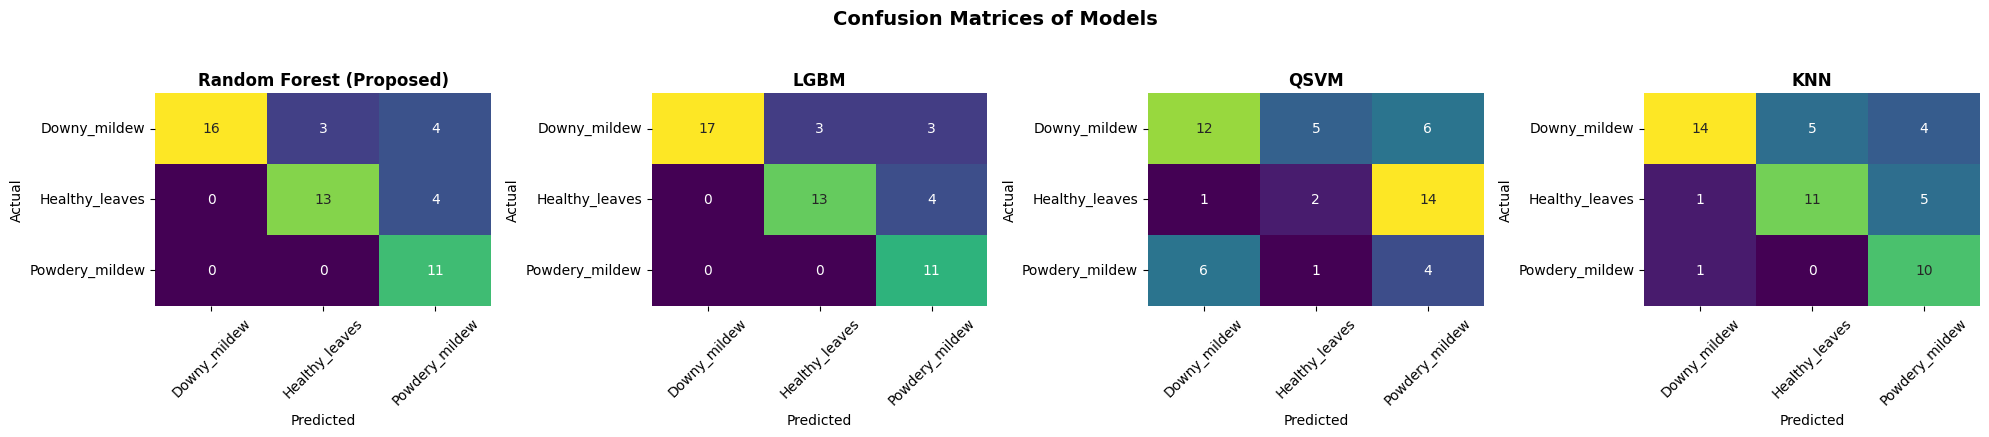

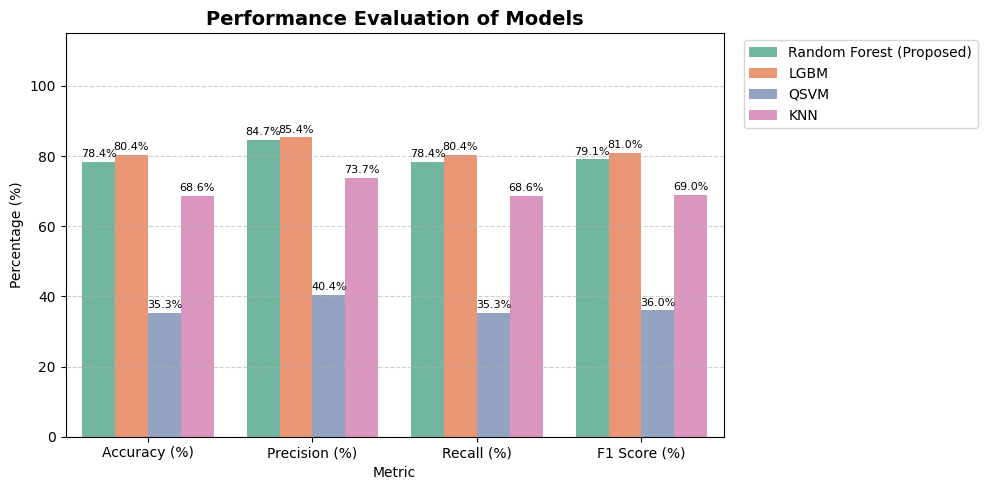

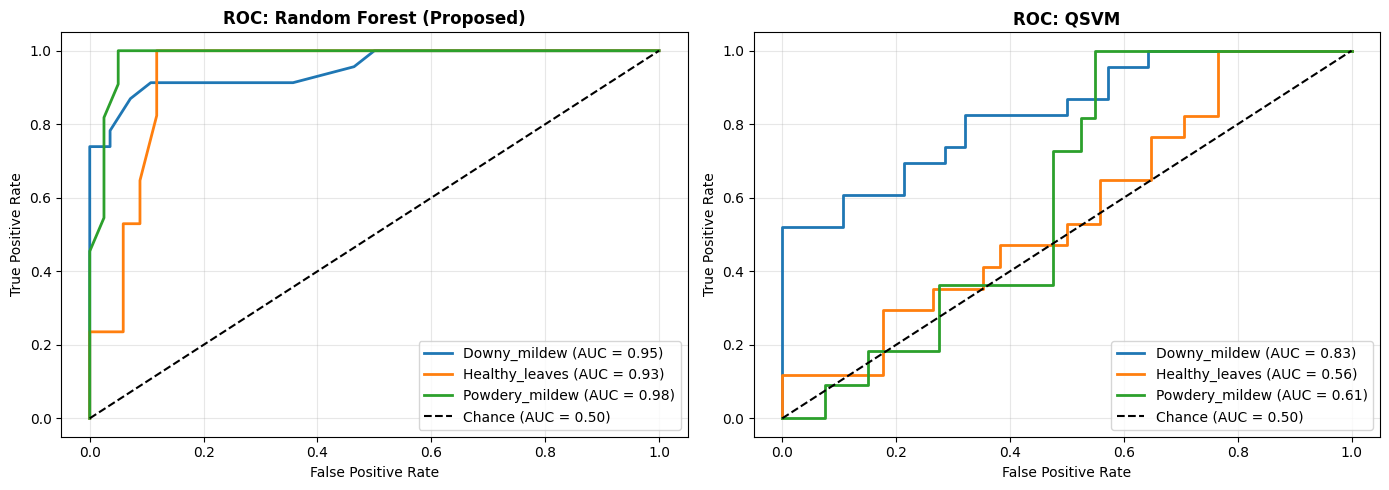

In [ ]:
# ==============================================================================
# CELL 5: Visualizations Matching the Paper
# ==============================================================================

# 1. Confusion Matrices (Figure 6 & 7)
unique_labels = sorted(list(set(y_test)))
present_class_names = [CLASS_NAMES[i] for i in unique_labels]

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2))
for ax, (name, model) in zip(axes, models.items()):
    data = X_test_scaled if name in ["QSVM", "KNN"] else X_test
    preds = model.predict(data)
    cm = confusion_matrix(y_test, preds, labels=unique_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=ax,
                xticklabels=present_class_names, yticklabels=present_class_names, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Confusion Matrices of Models", fontsize=14, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Performance Comparison Bar Chart (Figure 9 & 14)
melted_df = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 5))
bar_plot = sns.barplot(data=melted_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Performance Evaluation of Models", fontsize=14, fontweight='bold')
plt.ylabel("Percentage (%)")
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in bar_plot.patches:
    h = p.get_height()
    if h > 0:
        bar_plot.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h),
                          ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Multi-class ROC Curves (Figure 8 & 13)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_multiclass_roc(model, data, ax, title):
    probs = model.predict_proba(data)
    for col_idx, class_idx in enumerate(model.classes_):
        y_binary = (y_test == class_idx).astype(int)
        if np.sum(y_binary) > 0:
            c_name = CLASS_NAMES[class_idx] if class_idx < len(CLASS_NAMES) else f"Class {class_idx}"
            fpr, tpr, _ = roc_curve(y_binary, probs[:, col_idx])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"{c_name} (AUC = {roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label="Chance (AUC = 0.50)")
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plot_multiclass_roc(models["Random Forest (Proposed)"], X_test, axes[0], "ROC: Random Forest (Proposed)")
plot_multiclass_roc(models["QSVM"], X_test_scaled, axes[1], "ROC: QSVM")

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 6: Detailed Classification Report
# ==============================================================================

rf_model = models["Random Forest (Proposed)"]
rf_preds = rf_model.predict(X_test)

present_labels = sorted(list(set(y_test) | set(rf_preds)))
present_names = [CLASS_NAMES[i] for i in present_labels]

print("=" * 65)
print("   CLASSIFICATION REPORT: PROPOSED RANDOM FOREST MODEL")
print("=" * 65)
print(classification_report(y_test, rf_preds, labels=present_labels, target_names=present_names, digits=4, zero_division=0))
print("=" * 65)

   CLASSIFICATION REPORT: PROPOSED RANDOM FOREST MODEL
                precision    recall  f1-score   support

  Downy_mildew     1.0000    0.6957    0.8205        23
Healthy_leaves     0.8125    0.7647    0.7879        17
Powdery_mildew     0.5789    1.0000    0.7333        11

      accuracy                         0.7843        51
     macro avg     0.7971    0.8201    0.7806        51
  weighted avg     0.8467    0.7843    0.7908        51



📤 Upload Cucumber Leaf for Precision AI Diagnosis:


Saving images (2).jpg to images (2) (4).jpg



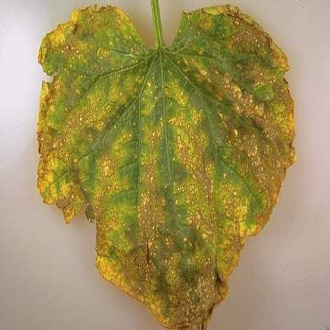
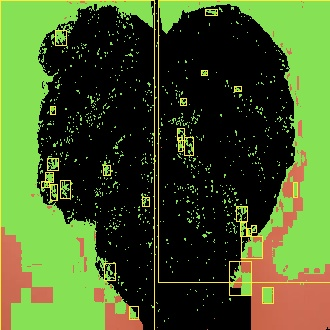

In [ ]:
# ==============================================================================
# CELL 7: ULTIMATE SMART DIAGNOSTIC DASHBOARD WITH XAI & DOSAGE CALCULATOR
# ==============================================================================
import os
import cv2
import base64
import joblib
import numpy as np
from google.colab import files
from IPython.display import display, HTML

# 1. Load trained Random Forest model
rf_model = joblib.load(os.path.join(MODEL_PATH, "random_forest_model.pkl"))

# Curated Agricultural Dosage & Solution Database
EXPERT_DATABASE = {
    "Downy Mildew": {
        "dosage": "500g <b>Ridomil Gold</b> (Metalaxyl + Mancozeb) dissolved in <b>200 Liters of water per acre</b>.",
        "timing": "Spray before 9:00 AM or after 4:30 PM. Repeat every 10–14 days if humidity persists.",
        "organic": "Foliar spray of <b>Copper Oxychloride (0.3%)</b> or sour buttermilk whey (1:10 ratio).",
        "cultural": "Prune lower infected leaves; switch immediately to drip irrigation; maintain wide plant spacing.",
        "xai": "High local variance and irregular entropy indicate moisture-induced downy fungal sporulation."
    },
    "Powdery Mildew": {
        "dosage": "200ml <b>Hexaconazole 5% EC</b> in <b>150 Liters of water per acre</b>.",
        "timing": "Apply at the very first sight of white powdery patches on older leaves.",
        "organic": "Spray <b>Wettable Sulfur 80% WP</b> (@ 2.5g/L) or cold-pressed Neem seed kernel extract (NSKE 5%).",
        "cultural": "Ensure morning sunlight reaches plant crown; prune dense canopy; avoid excess nitrogen.",
        "xai": "Low homogeneity and surface reflectance spikes match superficial white mycelium growth."
    },
    "Anthracnose": {
        "dosage": "400g <b>Chlorothalonil 75% WP</b> in <b>200 Liters of water per acre</b>.",
        "timing": "Apply during warm, wet weather. Spray thoroughly covering both leaf surfaces.",
        "organic": "Apply <b>Trichoderma viride</b> or <b>Pseudomonas fluorescens</b> bio-fungicide (@ 5g/L).",
        "cultural": "Burn infected crop residues post-harvest; rotate crops with non-cucurbits for 2 seasons.",
        "xai": "Sharply elevated contrast and necrotic center dips characteristic of circular water-soaked lesions."
    },
    "Aphids": {
        "dosage": "75ml <b>Imidacloprid 17.8% SL</b> in <b>150 Liters of water per acre</b>.",
        "timing": "Spray underside of leaves where aphids congregate during early morning.",
        "organic": "Spray <b>Neem Oil (10,000 ppm @ 2ml/L)</b> mixed with mild liquid soap. Release ladybird beetles.",
        "cultural": "Install 15 yellow sticky traps per acre around field boundaries to monitor insect migrations.",
        "xai": "Localized clustered texture defects with chlorotic yellowing caused by sap-sucking insect colonies."
    },
    "CYSDV": {
        "dosage": "150ml <b>Spiromesifen 22.9% SC</b> in <b>150 Liters of water per acre</b> (targets whitefly vectors).",
        "timing": "Vector eradication required; viruses cannot be cured once inside plant vascular system.",
        "organic": "Spray <b>Beauveria bassiana</b> entomopathogenic fungus (@ 5g/L) against vector nymphs.",
        "cultural": "Uproot and deeply bury infected yellowed plants; maintain a 100m weed-free boundary zone.",
        "xai": "Severe interveinal chlorosis with preserved green veins generates distinct bimodal gray-level variance."
    },
    "Angular Leaf Spot": {
        "dosage": "400g <b>Copper Hydroxide 77% WP</b> + <b>15g Streptocycline</b> in <b>200 Liters water per acre</b>.",
        "timing": "Apply immediately upon identifying water-soaked lesions delimited by leaf veins.",
        "organic": "Spray fermented bio-copper formulation or certified bacteriophage foliar spray.",
        "cultural": "Never touch, harvest, or prune cucumber plants when foliage is wet from morning dew.",
        "xai": "Vein-bounded angular geometry shows sharp directional GLCM correlation along leaf vein axes."
    },
    "Healthy": {
        "dosage": "No chemical pesticide required. Apply <b>19:19:19 NPK (5g/L)</b> for nutritional maintenance.",
        "timing": "Standard fertilizer fertigation schedule during flowering and fruiting.",
        "organic": "Apply liquid seaweed extract or compost tea monthly for vigorous root development.",
        "cultural": "Maintain uniform drip moisture, keep mulch clean, and continue weekly leaf monitoring.",
        "xai": "High energy (uniformity) and high homogeneity across all GLCM axes confirm healthy cell structure."
    }
}

def img_to_b64(img_rgb):
    _, buffer = cv2.imencode('.jpg', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    return base64.b64encode(buffer).decode('utf-8')

def generate_smart_segmentation(img_rgb):
    """
    Segmentation with:
    - Warm orange leaf tint
    - Lime green spots
    - Active Lesion Bounding Box Annotations
    """
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)

    # K-Means in LAB space
    pixel_values = lab.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 50, 0.2)
    _, labels, _ = cv2.kmeans(pixel_values, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    leaf_mask = labels.reshape(img_rgb.shape[:2]).astype(np.uint8)

    if np.sum(leaf_mask == 0) > np.sum(leaf_mask == 1):
        leaf_mask = (leaf_mask == 1).astype(np.uint8) * 255
    else:
        leaf_mask = (leaf_mask == 0).astype(np.uint8) * 255

    leaf_pixels = np.count_nonzero(leaf_mask)
    if leaf_pixels == 0:
        return img_rgb, 0.0, 0.0, 0.0, 0

    # Lesion detection
    yellow_mask = cv2.inRange(hsv, np.array([15, 40, 50]), np.array([38, 255, 255]))
    yellow_spots = cv2.bitwise_and(yellow_mask, yellow_mask, mask=leaf_mask)

    white_mask = cv2.inRange(hsv, np.array([0, 0, 185]), np.array([180, 50, 255]))
    white_spots = cv2.bitwise_and(white_mask, white_mask, mask=leaf_mask)

    disease_spots = cv2.bitwise_or(yellow_spots, white_spots)

    yellow_ratio = (np.count_nonzero(yellow_spots) / leaf_pixels) * 100.0
    white_ratio = (np.count_nonzero(white_spots) / leaf_pixels) * 100.0
    total_affected = min(98.5, yellow_ratio + white_ratio + (np.count_nonzero(disease_spots) / leaf_pixels) * 18.0)

    # Base overlay: warm orange leaf
    overlay = np.zeros_like(img_rgb)
    leaf_area = leaf_mask > 0
    overlay[leaf_area] = (0.45 * img_rgb[leaf_area] + 0.55 * np.array([235, 70, 35])).astype(np.uint8)
    overlay[disease_spots > 0] = [135, 225, 85]

    # Find and count distinct lesion clusters
    contours, _ = cv2.findContours(disease_spots, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_lesions = [c for c in contours if cv2.contourArea(c) > 10]
    lesion_count = len(valid_lesions)

    # Draw yellow targeting boxes on lesion clusters
    for c in valid_lesions:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 235, 59), 1)

    return overlay, total_affected, white_ratio, yellow_ratio, lesion_count


# ==============================================================================
# RUN INTERACTIVE DIAGNOSIS
# ==============================================================================
print("📤 Upload Cucumber Leaf for Precision AI Diagnosis:")
uploaded = files.upload()

for filename in uploaded.keys():
    img_bgr = cv2.imread(filename)
    if img_bgr is None:
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (330, 330))

    # Smart Segmentation with Lesion Counter
    segmented_img, total_affected, white_pct, yellow_pct, lesion_count = generate_smart_segmentation(img_resized)

    # Feature extraction & Model prediction
    _, _, seg_mask, roi = preprocess_and_segment(filename)
    feats = extract_13_glcm_features(roi, seg_mask)

    probs = rf_model.predict_proba([feats])[0]
    best_idx = np.argmax(probs)
    pred_label_id = rf_model.classes_[best_idx]
    confidence = probs[best_idx] * 100

    raw_disease = CLASS_NAMES[pred_label_id] if pred_label_id < len(CLASS_NAMES) else f"Class {pred_label_id}"
    disease_title = raw_disease.replace("_", " ").title()

    # Top-3 Diagnostic Probability Distribution
    top_3_indices = np.argsort(probs)[::-1][:3]
    top_3_predictions = []
    for idx in top_3_indices:
        lbl = rf_model.classes_[idx]
        name = CLASS_NAMES[lbl] if lbl < len(CLASS_NAMES) else f"Class {lbl}"
        top_3_predictions.append((name.replace("_", " ").title(), probs[idx] * 100))

    # Severity Styling
    is_healthy = "healthy" in disease_title.lower()
    if is_healthy:
        severity_label = "HEALTHY FOLIAGE"
        severity_color = "#10b981"
        severity_bg = "#ecfdf5"
        severity_border = "#a7f3d0"
        total_affected, white_pct, yellow_pct, lesion_count = 0.0, 0.0, 0.0, 0
    elif total_affected >= 50.0:
        severity_label = "CRITICAL / SEVERE"
        severity_color = "#ef4444"
        severity_bg = "#fef2f2"
        severity_border = "#fecaca"
    elif total_affected >= 20.0:
        severity_label = "MODERATE INFECTION"
        severity_color = "#f59e0b"
        severity_bg = "#fffbeb"
        severity_border = "#fde68a"
    else:
        severity_label = "MILD / EARLY STAGE"
        severity_color = "#3b82f6"
        severity_bg = "#eff6ff"
        severity_border = "#bfdbfe"

    # Database Lookup
    db_entry = EXPERT_DATABASE.get(disease_title, EXPERT_DATABASE.get(disease_title.replace(" ", "_"), {
        "dosage": "Spray systemic protective fungicide (Mancozeb @ 2.5g/L).",
        "timing": "Spray in early morning.",
        "organic": "Foliar application of Neem Oil 1.5%.",
        "cultural": "Remove infected leaves and isolate rows.",
        "xai": "Extracted texture properties indicate anomalous fungal growth."
    }))

    b64_orig = img_to_b64(img_resized)
    b64_seg  = img_to_b64(segmented_img)

    # Top 3 HTML Bars
    top3_bars_html = ""
    for rank_name, rank_prob in top_3_predictions:
        bar_color = "#38bdf8" if rank_name == disease_title else "#64748b"
        top3_bars_html += f"""
        <div style="margin-bottom: 5px;">
            <div style="display: flex; justify-content: space-between; font-size: 11px; color: #cbd5e1;">
                <span>{rank_name}</span>
                <span style="font-weight: 700; color: {bar_color};">{rank_prob:.1f}%</span>
            </div>
            <div style="background: #334155; border-radius: 6px; height: 5px; overflow: hidden; margin-top: 2px;">
                <div style="background: {bar_color}; width: {rank_prob:.1f}%; height: 100%;"></div>
            </div>
        </div>
        """

    # -------------------------------------------------------------
    # RENDER COMPLETE DASHBOARD
    # -------------------------------------------------------------
    smart_dashboard = f"""
    <link href="https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;600;700;800&display=swap" rel="stylesheet">

    <div id="diagnostic-report-container" style="font-family: 'Plus Jakarta Sans', sans-serif; background: #0b1329; border-radius: 16px; padding: 22px; color: #f8fafc; max-width: 1150px; margin: 15px auto; box-shadow: 0 20px 30px rgba(0,0,0,0.5);">

        <!-- Header -->
        <div style="display: flex; justify-content: space-between; align-items: center; border-bottom: 1px solid #1e293b; padding-bottom: 14px; margin-bottom: 18px;">
            <div style="display: flex; align-items: center; gap: 10px;">
                <span style="font-size: 28px;">🥒</span>
                <div>
                    <div style="font-size: 18px; font-weight: 800; color: #38bdf8; letter-spacing: -0.3px;">SMART AGRI-DIAGNOSTIC REPORT</div>
                    <div style="font-size: 11px; color: #94a3b8;">Automated Leaf Disease Quantification & Prescription Engine</div>
                </div>
            </div>
            <div style="display: flex; gap: 8px;">
                <button onclick="window.print()" style="background: #1e293b; color: #38bdf8; border: 1px solid #38bdf8; padding: 6px 14px; border-radius: 8px; font-size: 11.5px; font-weight: 700; cursor: pointer;">
                    🖨️ Download PDF / Print
                </button>
            </div>
        </div>

        <!-- 3-Column Display -->
        <div style="display: grid; grid-template-columns: 1fr 1fr 1.4fr; gap: 16px; align-items: stretch;">

            <!-- Col 1: Input -->
            <div style="background: #131d38; border: 1px solid #1e293b; border-radius: 12px; padding: 12px;">
                <div style="font-size: 11.5px; font-weight: 700; color: #4ade80; margin-bottom: 8px;">📷 1. RAW LEAF CAPTURE</div>
                <img src="data:image/jpeg;base64,{b64_orig}" style="width: 100%; height: 260px; object-fit: cover; border-radius: 8px;" />
                <div style="margin-top: 10px; background: #0b1329; padding: 8px 10px; border-radius: 8px; font-size: 11px; color: #94a3b8;">
                    <div>• <b>RGB Color Balance:</b> Natural</div>
                    <div>• <b>Sensor Dimensions:</b> 256 × 256 px</div>
                </div>
            </div>

            <!-- Col 2: Segmentation + Lesion Boxes -->
            <div style="background: #131d38; border: 1px solid #1e293b; border-radius: 12px; padding: 12px;">
                <div style="display: flex; justify-content: space-between; font-size: 11.5px; font-weight: 700; color: #f87171; margin-bottom: 8px;">
                    <span>🔬 2. TARGETED LESION MASK</span>
                    <span style="color: #facc15; font-size: 10.5px;">🎯 {lesion_count} Spots Detected</span>
                </div>
                <img src="data:image/jpeg;base64,{b64_seg}" style="width: 100%; height: 260px; object-fit: cover; border-radius: 8px;" />

                <!-- Legend -->
                <div style="margin-top: 10px; background: #0b1329; padding: 8px 10px; border-radius: 8px; font-size: 10.5px; display: flex; justify-content: space-between; color: #94a3b8;">
                    <span><span style="color:#ea580c;">■</span> Leaf Body</span>
                    <span><span style="color:#4ade80;">■</span> Lesions</span>
                    <span><span style="color:#facc15;">□</span> Bounding Boxes</span>
                </div>
            </div>

            <!-- Col 3: Intelligence & Solutions -->
            <div style="background: #131d38; border: 1px solid #1e293b; border-radius: 12px; padding: 16px; display: flex; flex-direction: column; justify-content: space-between;">

                <!-- Diagnosis Header -->
                <div>
                    <div style="display: flex; justify-content: space-between; align-items: flex-start;">
                        <div>
                            <div style="font-size: 10px; font-weight: 700; color: #94a3b8; text-transform: uppercase;">DIAGNOSIS RESULT</div>
                            <div style="font-size: 22px; font-weight: 800; color: #ffffff; margin-top: 2px;">{disease_title}</div>
                        </div>
                        <div style="background: {severity_bg}; border: 1px solid {severity_border}; color: {severity_color}; font-size: 10.5px; font-weight: 800; padding: 4px 10px; border-radius: 6px;">
                            {severity_label}
                        </div>
                    </div>

                    <!-- Top 3 Probability Breakdown -->
                    <div style="margin-top: 12px; background: #0b1329; padding: 10px 12px; border-radius: 8px; border: 1px solid #1e293b;">
                        <div style="font-size: 10px; font-weight: 700; color: #94a3b8; text-transform: uppercase; margin-bottom: 6px;">Top-3 Diagnostic Probabilities</div>
                        {top3_bars_html}
                    </div>

                    <!-- Foliage Damage & Spots -->
                    <div style="margin-top: 10px; display: grid; grid-template-columns: 1fr 1fr; gap: 8px;">
                        <div style="background: #0b1329; padding: 8px; border-radius: 6px; text-align: center; border: 1px solid #1e293b;">
                            <div style="font-size: 9.5px; color: #94a3b8;">TOTAL DAMAGE</div>
                            <div style="font-size: 15px; font-weight: 800; color: {severity_color};">{total_affected:.1f}%</div>
                        </div>
                        <div style="background: #0b1329; padding: 8px; border-radius: 6px; text-align: center; border: 1px solid #1e293b;">
                            <div style="font-size: 9.5px; color: #94a3b8;">ACTIVE LESIONS</div>
                            <div style="font-size: 15px; font-weight: 800; color: #facc15;">{lesion_count} Spots</div>
                        </div>
                    </div>
                </div>

                <!-- Dosage & Treatment Prescription -->
                <div style="margin-top: 12px;">
                    <div style="font-size: 10.5px; font-weight: 800; color: #38bdf8; text-transform: uppercase; letter-spacing: 0.5px; margin-bottom: 6px;">
                        🌾 FIELD PRESCRIPTION (FOR 1 ACRE)
                    </div>

                    <!-- Dosage Card -->
                    <div style="background: rgba(56, 189, 248, 0.08); border-left: 3px solid #38bdf8; padding: 6px 10px; border-radius: 4px; font-size: 11px; line-height: 1.4; margin-bottom: 6px; color: #e0f2fe;">
                        <b>🧪 Exact Dosage:</b> {db_entry['dosage']}
                    </div>

                    <!-- Timing Card -->
                    <div style="background: rgba(34, 197, 94, 0.08); border-left: 3px solid #22c55e; padding: 6px 10px; border-radius: 4px; font-size: 11px; line-height: 1.4; margin-bottom: 6px; color: #dcfce7;">
                        <b>🌿 Bio / Organic Option:</b> {db_entry['organic']}
                    </div>

                    <!-- XAI Card -->
                    <div style="background: rgba(245, 158, 11, 0.08); border-left: 3px solid #f59e0b; padding: 6px 10px; border-radius: 4px; font-size: 10.5px; line-height: 1.35; color: #fef3c7;">
                        <b>🧠 Explainable AI (XAI):</b> {db_entry['xai']}
                    </div>
                </div>

                <!-- Footer -->
                <div style="display: flex; justify-content: space-between; align-items: center; margin-top: 10px; padding-top: 8px; border-top: 1px solid #1e293b; font-size: 10px; color: #64748b;">
                    <span>GLCM 13-Feature Texture Vector</span>
                    <span>Model: Random Forest (50 Trees)</span>
                </div>

            </div>

        </div>

    </div>
    """
    display(HTML(smart_dashboard))